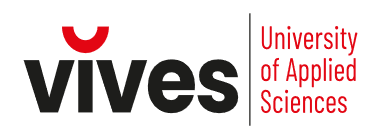<br>


**MACHINE LEARNING FUNDAMENTALS**<br>
APPLIED COMPUTER SCIENCE<br>
Specialization in Artificial Intelligence<br>
Andy Louwyck

---



---



# **DOT PRODUCT**

## Introduction

The dot product, also known as the **scalar or inner product**, is an algebraic operation that takes two equal-length sequences of numbers (usually vectors) and returns a single number. The dot product is useful in various applications, and it is also frequently used in machine learning and deep learning.

**Definition**:
For two vectors **u** and **v** in an N-dimensional space, the dot product is defined as:

$$
\mathbf{u} \cdot \mathbf{v} = \sum_{i=1}^{N} u_i v_i = u_1v_1+u_2v_2+...+u_Nv_N
$$

**Example**:
Let's say we have two vectors **u** = [1, 2, 3] and **v** = [4, 5, 6]. The dot product is calculated as:

$$
\mathbf{u} \cdot \mathbf{v} = (1 \cdot 4) + (2 \cdot 5) + (3 \cdot 6) = 4 + 10 + 18 = 32
$$

**In linear regression and linear classification**, the dot product is used to calculate the weighted sum of the features:

$$
z_i = \mathbf{X}_i \cdot \mathbf{w} = \sum_{j=1}^{m} X_{ij} w_j = X_{i,1}w_1+X_{i,2}w_2+...+X_{i,m}w_m
$$

where:
- $z_i$ is the weighted sum of the features of sample $i$
- $\mathbf{X}_i$ is the 1 x $m$ vector with the features of sample $i$
- $\mathbf{w}$ is the 1 x $m$ vector with the weights for each feature
- $m$ is the number of features
- $X_{ij}$ is feature $j$ of sample $i$
- $w_j$ is the weight of feature $j$

We see that the dot product is applied between each sample (row) $i$ in matrix $\mathbf{X}$ and the weight vector $\mathbf{w}$. Actually, we can apply **matrix multiplication** between matrix $\mathbf{X}$ and vector $\mathbf{w}$ so that we don't need to loop over the samples (rows) of $\mathbf{X}$:

$$
\mathbf{z} = \mathbf{X} \cdot \mathbf{w}^T
$$

where:
- $\mathbf{z}$ is the $n$ x 1 vector with the weighted sums of all samples
- $\mathbf{X}$ is the $n$ x $m$ matrix with the features of all samples
- $\mathbf{w}$ is the 1 x $m$ vector with the weights

Here, we need to transpose row vector $\mathbf{w}$ because the number of rows must match the number of columns in $\mathbf{X}$. The result is column vector $\mathbf{z}$ with the weighted sums of all samples.

In NumPy, both the scalar product and matrix multiplication can be done by applying the **`dot()` function**.

If `w` is a 1D array:

```python
z = np.dot(X, w)
```

If `w` is a 2D array consisting of 1 row:

```python
z = np.dot(X, w.T)  # transpose!
```


Instead of applying function `dot()`, it is also possible to use the `@` operator:

```python
z = X @ w
```


## Example

In this example, we'll show how the dot product is applied to make predictions in linear regression.

Import pandas and NumPy:

In [30]:
import pandas as pd
import numpy as np

Read the Excel-file into a pandas DataFrame:

In [31]:
df = pd.read_excel('house_data.xlsx')
df

,Size (sqft),Number of Rooms,Age of House (years),Distance to City Center (miles),House Type,House Price ($1000s)
0,3961,1,8,16.859203,Detached,350
1,2568,3,19,1.873115,Townhouse,240
2,3503,1,41,12.743941,Townhouse,267
3,3505,5,2,6.461092,Apartment,360
4,3234,1,92,1.969252,Townhouse,140
5,3247,3,96,19.084901,Detached,50
6,3985,3,89,9.991472,Detached,130
7,3959,1,68,6.898977,Apartment,150
8,830,5,1,10.130927,Apartment,75
9,3674,1,61,7.759514,Townhouse,290


Get DataFrame info:

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Size (sqft)                      10 non-null     int64  
 1   Number of Rooms                  10 non-null     int64  
 2   Age of House (years)             10 non-null     int64  
 3   Distance to City Center (miles)  10 non-null     float64
 4   House Type                       10 non-null     object 
 5   House Price ($1000s)             10 non-null     int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 612.0+ bytes


Encode the House Type using method `map()`:

In [33]:
df['House Type'] = df['House Type'].map({'Apartment': 0, 'Townhouse': 1, 'Detached': 2})
df.head()

,Size (sqft),Number of Rooms,Age of House (years),Distance to City Center (miles),House Type,House Price ($1000s)
0,3961,1,8,16.859203,2,350
1,2568,3,19,1.873115,1,240
2,3503,1,41,12.743941,1,267
3,3505,5,2,6.461092,0,360
4,3234,1,92,1.969252,1,140


Put the randomly chosen weights in a DataFrame:

In [34]:
weights = pd.DataFrame(data=np.array([[0.1, 0.5, 0.01, -0.1, 0.5]]),
                       columns=df.columns[:-1])
weights

,Size (sqft),Number of Rooms,Age of House (years),Distance to City Center (miles),House Type
0,0.1,0.5,0.01,-0.1,0.5


Determine target `y` and features `X`, which both are NumPy arrays, and also define array `w` with weights:

In [35]:
y = df['House Price ($1000s)'].values  # get numpy array from values
X = df.drop(columns=['House Price ($1000s)'], axis=1).values
w = weights.values.flatten()

Use two nested **`for`-loops** to calculate the weighted sum `z` of all features `j` for each sample `i`:

In [36]:
nrow, ncol = X.shape
z = np.zeros(nrow)
for i in range(nrow):
    for j in range(ncol):
        z[i] += X[i][j] * w[j]
z

array([395.99407967, 258.80268854, 350.43560589, 352.37389081,
       325.1230748 , 326.2515099 , 400.8908528 , 396.3901023 ,
        84.49690726, 368.23404861])

In NumPy, it is, however, more efficient to use a **vectorized expression** without `for`-loops:

In [37]:
np.sum(X * w, axis=1)  # axis=1 because we want the sum of the rows!

array([395.99407967, 258.80268854, 350.43560589, 352.37389081,
       325.1230748 , 326.2515099 , 400.8908528 , 396.3901023 ,
        84.49690726, 368.23404861])

And it is even more efficient to use the **`dot()` function**:

In [38]:
np.dot(X, w)

array([395.99407967, 258.80268854, 350.43560589, 352.37389081,
       325.1230748 , 326.2515099 , 400.8908528 , 396.3901023 ,
        84.49690726, 368.23404861])

Alternatively, the `@` operator can be used instead of function `dot()`:

In [39]:
X @ w

array([395.99407967, 258.80268854, 350.43560589, 352.37389081,
       325.1230748 , 326.2515099 , 400.8908528 , 396.3901023 ,
        84.49690726, 368.23404861])

Note that a DataFrame object also has a `dot()` method:

In [40]:
df[df.columns[:-1]].dot(weights.T)  # T to transpose weights!

,0
0,395.994080
1,258.802689
2,350.435606
3,352.373891
4,325.123075
5,326.251510
6,400.890853
7,396.390102
8,84.496907
9,368.234049


Note that we need to transpose the `weights` DataFrame, because it is a 2D matrix consisting of 1 row, and it should be a 2D matrix consisting of 1 column. Can you explain why?

Here, we predicted the house prices using randomly chosen `weights`. However, machine learning is about applying a learning algorithm that finds the optimal values for the weights from the given data so that the model makes the best possible predictions.

Let's do that using `LinearRegression` from Scikit-Learn:

In [41]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)
model.score(X, y)

0.8878522803778223

We get a R² score of 0.89, which is not bad. Let's make the predictions:

In [42]:
model.predict(X)

array([373.91674325, 259.31004088, 241.88259183, 328.4880149 ,
       125.97740985,  36.90121898, 162.36682657, 212.47383201,
        87.22294189, 223.46037984])

These are the optimal weights determined by the linear regression algorithm:

In [43]:
model.coef_  # weights w

array([ 0.08474254, -8.55528649, -2.82774991, -4.74313517, 19.4255656 ])

In this case, the algorithm also determines the intercept or bias:

In [44]:
model.intercept_  # bias b

np.float64(110.54317363559979)

Actually we could calculate the predictions by ourselves using these model parameters:

In [45]:
X @ model.coef_ + model.intercept_  # the same as X @ w + b

array([373.91674325, 259.31004088, 241.88259183, 328.4880149 ,
       125.97740985,  36.90121898, 162.36682657, 212.47383201,
        87.22294189, 223.46037984])

We get the same predictions indeed!

---